# Uncertainty-Accuracy Analysis

This notebook analyzes the relationship between model uncertainty and prediction accuracy by dividing the test set into 5 categories based on uncertainty levels.

The process:
1. Load the best model from W&B artifacts
2. Run Monte Carlo predictions on the test set
3. Divide predictions into 5 uncertainty buckets (very low → very high)
4. Compare accuracy across uncertainty levels
5. Visualize the results

In [12]:
%pip install wandb

In [13]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import wandb

IS_COLAB = "COLAB_GPU" in os.environ

if IS_COLAB:
    PROJECT_ROOT = Path("/content/DAT255_Bayesian")
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

Project root: /content/DAT255_Bayesian
TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
import re

WANDB_PROJECT = "dat255-bayesian"
WANDB_ENTITY = None
WANDB_BEST_MODEL_ARTIFACT = "notebook-04-best-model"

# Load W&B API key from streamlit secrets.toml
# secrets_path = PROJECT_ROOT / "streamlit" / "secrets.toml"
# if secrets_path.exists():
#     with open(secrets_path, "r") as f:
#         content = f.read()
    
#     # Parse WANDB_API_KEY from TOML
#     match = re.search(r'WANDB_API_KEY\s*=\s*["\']([^"\']+)["\']', content)
#     if match:
#         WANDB_API_KEY = match.group(1)
#         print(f"✓ Loaded W&B API key from {secrets_path}")
#     else:
#         raise ValueError(f"WANDB_API_KEY not found in {secrets_path}")
# else:
#     raise ValueError(f"secrets.toml not found at {secrets_path}")
key = "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"
wandb.login(key)


def _artifact_reference(artifact_name: str, alias: str = "latest") -> str:
    api = wandb.Api()
    entity = WANDB_ENTITY or getattr(api, "default_entity", None)
    if entity:
        return f"{entity}/{WANDB_PROJECT}/{artifact_name}:{alias}"
    return f"{WANDB_PROJECT}/{artifact_name}:{alias}"


def download_artifact_file(artifact_name: str, *, alias: str = "latest", filename: str | None = None) -> Path:
    artifact = wandb.Api().artifact(_artifact_reference(artifact_name, alias))
    download_root = PROJECT_ROOT / "artifacts" / "wandb" / "downloads" / artifact_name
    artifact_dir = Path(artifact.download(root=str(download_root)))

    if filename is not None:
        return artifact_dir / filename

    files = [item for item in artifact_dir.iterdir() if item.is_file()]
    if len(files) != 1:
        raise FileNotFoundError(
            f"Expected exactly one file in artifact {artifact_name}, found {len(files)}."
        )
    return files[0]

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [15]:
class MCDropout(tf.keras.layers.Dropout):
    """Dropout layer that stays active during inference for MC sampling."""

    def call(self, inputs, training=None):
        return super().call(inputs, training=True)


def mc_predict(
    model: tf.keras.Model,
    images: tf.Tensor,
    mc_samples: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Run several stochastic forward passes and summarize the predictions."""
    predictions = []
    for _ in range(mc_samples):
        predictions.append(model(images, training=False).numpy())

    stacked = np.stack(predictions, axis=0)
    mean_prediction = stacked.mean(axis=0)
    variance = stacked.var(axis=0)
    predictive_entropy = -np.sum(
        mean_prediction * np.log(mean_prediction + 1e-10),
        axis=1,
    )
    return mean_prediction, variance, predictive_entropy

## Configuration

Define data paths and hyperparameters for the analysis.

In [16]:
# Configuration for data and analysis
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"
IMAGENETTE_MD5 = "e793b78cc4c9e9a4ccc0c1155377a412"
IMAGENETTE_FOLDER_NAME = "imagenette2-160"
DATASET_SEED = 255

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64
NUM_CLASSES = 10
MC_SAMPLES = 30
NUM_UNCERTAINTY_BINS = 5
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(f"Image size: {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"MC samples: {MC_SAMPLES}")
print(f"Number of uncertainty bins: {NUM_UNCERTAINTY_BINS}")

Image size: (128, 128)
Batch size: 64
MC samples: 30
Number of uncertainty bins: 5


## Data Loading

Download ImageNette and create the test dataset.

In [17]:
def find_imagenette_dir(raw_data_dir: Path) -> Path | None:
    """Find the extracted ImageNette folder inside the raw data directory."""
    candidates = [
        raw_data_dir / IMAGENETTE_FOLDER_NAME,
        raw_data_dir / f"{IMAGENETTE_FOLDER_NAME}.tgz" / IMAGENETTE_FOLDER_NAME,
    ]

    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "val").is_dir():
            return candidate

    return None


def ensure_imagenette_dataset(raw_data_dir: Path) -> Path:
    """Reuse ImageNette if it already exists, otherwise download it once."""
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    dataset_dir = find_imagenette_dir(raw_data_dir)

    if dataset_dir is not None:
        print(f"ImageNette already exists at: {dataset_dir}")
        return dataset_dir

    print("ImageNette not found. Downloading to data/raw...")
    tf.keras.utils.get_file(
        origin=IMAGENETTE_URL,
        file_hash=IMAGENETTE_MD5,
        cache_dir=str(raw_data_dir),
        cache_subdir="",
        extract=True,
    )

    dataset_dir = find_imagenette_dir(raw_data_dir)
    if dataset_dir is None:
        raise FileNotFoundError("ImageNette was downloaded, but the dataset folder could not be found.")

    print(f"ImageNette downloaded to: {dataset_dir}")
    return dataset_dir


def load_test_dataset() -> tuple[tf.data.Dataset, list[str]]:
    """Create the test dataset from ImageNette."""
    imagenette_dir = ensure_imagenette_dataset(RAW_DATA_DIR)
    test_dir = imagenette_dir / "val"
    
    # Get class names sorted alphabetically
    class_names = sorted(path.name for path in test_dir.iterdir() if path.is_dir())

    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=str(test_dir),
        labels="inferred",
        label_mode="categorical",
        batch_size=BATCH_SIZE,
        image_size=IMAGE_SIZE,
        shuffle=False,
        seed=DATASET_SEED,
    ).prefetch(tf.data.AUTOTUNE)

    print(f"Test dataset loaded from: {test_dir}")
    print(f"Number of classes: {len(class_names)}")
    print(f"Class names: {class_names}")
    
    return test_ds, class_names


# Load the test dataset
test_ds, class_names = load_test_dataset()

ImageNette already exists at: /content/DAT255_Bayesian/data/raw/imagenette2-160.tgz/imagenette2-160
Found 3925 files belonging to 10 classes.
Test dataset loaded from: /content/DAT255_Bayesian/data/raw/imagenette2-160.tgz/imagenette2-160/val
Number of classes: 10
Class names: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


## Load Model from W&B

Download and load the best model from W&B artifacts.

In [18]:
print("Downloading model from W&B artifacts...")
model_path = download_artifact_file(WANDB_BEST_MODEL_ARTIFACT, alias="latest")
print(f"Model downloaded to: {model_path}")

print("Loading model...")
model = tf.keras.models.load_model(
    model_path,
    custom_objects={"MCDropout": MCDropout},
)
print("Model loaded successfully!")
print(model.summary())

wandb:   1 of 1 files downloaded.  


Model downloaded to: /content/DAT255_Bayesian/artifacts/wandb/downloads/notebook-04-best-model/dropout_0_1.keras
Loading model...
Model loaded successfully!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_5 (MCDropout)        │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_6 (MCDropout)        │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_7 (MCDropout)        │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_8 (MCDropout)        │ (None, 8, 8, 512)      │             

 Total params: 4,862,496 (18.55 MB)

 Trainable params: 1,620,106 (6.18 MB)

 Non-trainable params: 2,176 (8.50 KB)

 Optimizer params: 3,240,214 (12.36 MB)

None


## Run MC Dropout Predictions

Run multiple forward passes to get uncertainty estimates for each prediction.

In [19]:
print("Running MC predictions on test set...")

all_true_classes = []
all_predicted_classes = []
all_predictive_entropies = []
all_mean_variances = []
all_max_probs = []

for images, labels in test_ds:
    mean_prediction, variance, predictive_entropy = mc_predict(
        model,
        images,
        MC_SAMPLES,
    )

    predicted_classes = mean_prediction.argmax(axis=1)
    true_classes = labels.numpy().argmax(axis=1)
    batch_mean_variance = variance.mean(axis=1)
    max_probs = mean_prediction.max(axis=1)

    all_true_classes.extend(true_classes.tolist())
    all_predicted_classes.extend(predicted_classes.tolist())
    all_predictive_entropies.extend(predictive_entropy.tolist())
    all_mean_variances.extend(batch_mean_variance.tolist())
    all_max_probs.extend(max_probs.tolist())

# Convert to numpy arrays for easier manipulation
all_true_classes = np.array(all_true_classes)
all_predicted_classes = np.array(all_predicted_classes)
all_predictive_entropies = np.array(all_predictive_entropies)
all_mean_variances = np.array(all_mean_variances)
all_max_probs = np.array(all_max_probs)

# Calculate per-sample accuracy
correct = (all_true_classes == all_predicted_classes).astype(int)

print(f"Total predictions: {len(all_true_classes)}")
print(f"Overall accuracy: {correct.mean():.4f}")
print(f"\nUncertainty statistics (using variance):")
print(f"  Min variance: {all_mean_variances.min():.6f}")
print(f"  Max variance: {all_mean_variances.max():.6f}")
print(f"  Mean variance: {all_mean_variances.mean():.6f}")
print(f"  Std variance: {all_mean_variances.std():.6f}")

print(f"\nUncertainty statistics (using entropy):")
print(f"  Min entropy: {all_predictive_entropies.min():.6f}")
print(f"  Max entropy: {all_predictive_entropies.max():.6f}")
print(f"  Mean entropy: {all_predictive_entropies.mean():.6f}")
print(f"  Std entropy: {all_predictive_entropies.std():.6f}")

print(f"\nConfidence statistics:")
print(f"  Min confidence: {all_max_probs.min():.6f}")
print(f"  Max confidence: {all_max_probs.max():.6f}")
print(f"  Mean confidence: {all_max_probs.mean():.6f}")
print(f"  Std confidence: {all_max_probs.std():.6f}")

Running MC predictions on test set...
Total predictions: 3925
Overall accuracy: 0.7990

Uncertainty statistics (using variance):
  Min variance: 0.000000
  Max variance: 0.023039
  Mean variance: 0.002620
  Std variance: 0.003652

Uncertainty statistics (using entropy):
  Min entropy: 0.000000
  Max entropy: 2.033438
  Mean entropy: 0.462146
  Std entropy: 0.512450

Confidence statistics:
  Min confidence: 0.226746
  Max confidence: 1.000000
  Mean confidence: 0.841732
  Std confidence: 0.202017


## Divide Test Set into Uncertainty Bins

Create 5 bins based on variance and analyze accuracy in each bin.

In [20]:
# Divide predictions into bins based on variance (uncertainty)
# Use qcut to ensure equal-sized bins
bin_indices = pd.qcut(all_mean_variances, q=NUM_UNCERTAINTY_BINS, labels=False, duplicates='drop')

# Create labels for bins
bin_labels = ["Very Low", "Low", "Medium", "High", "Very High"]
if len(np.unique(bin_indices)) < NUM_UNCERTAINTY_BINS:
    bin_labels = bin_labels[:len(np.unique(bin_indices))]

# Analyze each bin
results = []
bin_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(np.unique(bin_indices))))

print(f"\n{'Bin':<12} {'Label':<12} {'Count':<8} {'Accuracy':<10} {'Avg Var':<12} {'Avg Entropy':<12} {'Avg Conf':<10}")
print("-" * 80)

for bin_idx, label in enumerate(bin_labels[:len(np.unique(bin_indices))]):
    mask = bin_indices == bin_idx
    bin_count = mask.sum()
    bin_accuracy = correct[mask].mean()
    bin_avg_variance = all_mean_variances[mask].mean()
    bin_avg_entropy = all_predictive_entropies[mask].mean()
    bin_avg_confidence = all_max_probs[mask].mean()
    
    results.append({
        'bin': bin_idx,
        'label': label,
        'count': int(bin_count),
        'accuracy': float(bin_accuracy),
        'avg_variance': float(bin_avg_variance),
        'avg_entropy': float(bin_avg_entropy),
        'avg_confidence': float(bin_avg_confidence),
    })
    
    print(f"{bin_idx:<12} {label:<12} {bin_count:<8} {bin_accuracy:<10.4f} {bin_avg_variance:<12.6f} {bin_avg_entropy:<12.6f} {bin_avg_confidence:<10.4f}")

# Create DataFrame for easier analysis
results_df = pd.DataFrame(results)
print(f"\nOverall accuracy: {correct.mean():.4f}")


Bin          Label        Count    Accuracy   Avg Var      Avg Entropy  Avg Conf  
--------------------------------------------------------------------------------
0            Very Low     785      0.9911     0.000000     0.002431     0.9998    
1            Low          785      0.9809     0.000015     0.042580     0.9938    
2            Medium       785      0.8892     0.000577     0.267056     0.9437    
3            High         785      0.6280     0.003690     0.887298     0.7158    
4            Very High    785      0.5057     0.008821     1.111363     0.5555    

Overall accuracy: 0.7990


## Visualize Results

Create plots to visualize the relationship between uncertainty and accuracy.

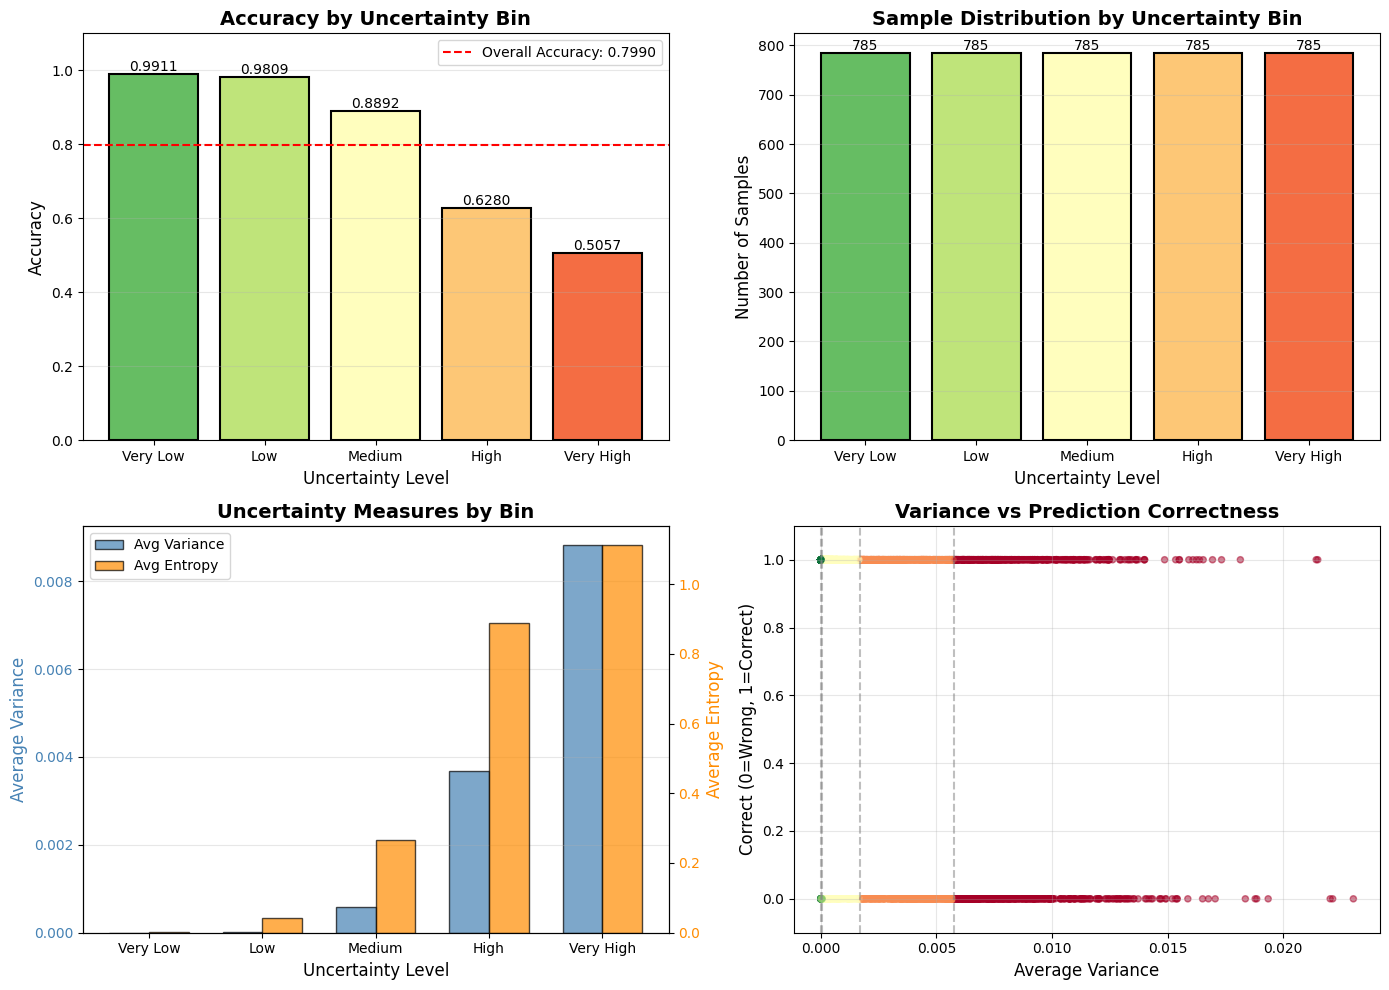


Visualization complete!


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy by uncertainty bin
ax = axes[0, 0]
bin_labels_plot = results_df['label'].values
accuracies = results_df['accuracy'].values
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(results_df)))

bars = ax.bar(bin_labels_plot, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax.axhline(y=correct.mean(), color='red', linestyle='--', label=f'Overall Accuracy: {correct.mean():.4f}')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Uncertainty Level', fontsize=12)
ax.set_title('Accuracy by Uncertainty Bin', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Number of samples per bin
ax = axes[0, 1]
counts = results_df['count'].values
ax.bar(bin_labels_plot, counts, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_xlabel('Uncertainty Level', fontsize=12)
ax.set_title('Sample Distribution by Uncertainty Bin', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (label, count) in enumerate(zip(bin_labels_plot, counts)):
    ax.text(i, count, str(count), ha='center', va='bottom', fontsize=10)

# Plot 3: Average variance and entropy by bin
ax = axes[1, 0]
x = np.arange(len(bin_labels_plot))
width = 0.35

ax2 = ax.twinx()
bars1 = ax.bar(x - width/2, results_df['avg_variance'].values, width, label='Avg Variance', color='steelblue', alpha=0.7, edgecolor='black')
bars2 = ax2.bar(x + width/2, results_df['avg_entropy'].values, width, label='Avg Entropy', color='darkorange', alpha=0.7, edgecolor='black')

ax.set_ylabel('Average Variance', fontsize=12, color='steelblue')
ax2.set_ylabel('Average Entropy', fontsize=12, color='darkorange')
ax.set_xlabel('Uncertainty Level', fontsize=12)
ax.set_title('Uncertainty Measures by Bin', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bin_labels_plot)
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax.grid(axis='y', alpha=0.3)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Plot 4: Scatter plot of variance vs accuracy
ax = axes[1, 1]
scatter = ax.scatter(all_mean_variances, correct, alpha=0.5, c=bin_indices, cmap='RdYlGn_r', s=20)
ax.set_xlabel('Average Variance', fontsize=12)
ax.set_ylabel('Correct (0=Wrong, 1=Correct)', fontsize=12)
ax.set_title('Variance vs Prediction Correctness', fontsize=14, fontweight='bold')
ax.set_ylim([-0.1, 1.1])
ax.grid(alpha=0.3)

# Add bin lines
for i in range(len(results_df) - 1):
    bin_boundary = all_mean_variances[bin_indices == i].max()
    ax.axvline(x=bin_boundary, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

## Image Examples by Uncertainty Bin

Visualize sample predictions from each uncertainty bin to understand model behavior.

Selecting random example images from each uncertainty bin...
Images collected! (25 total images)


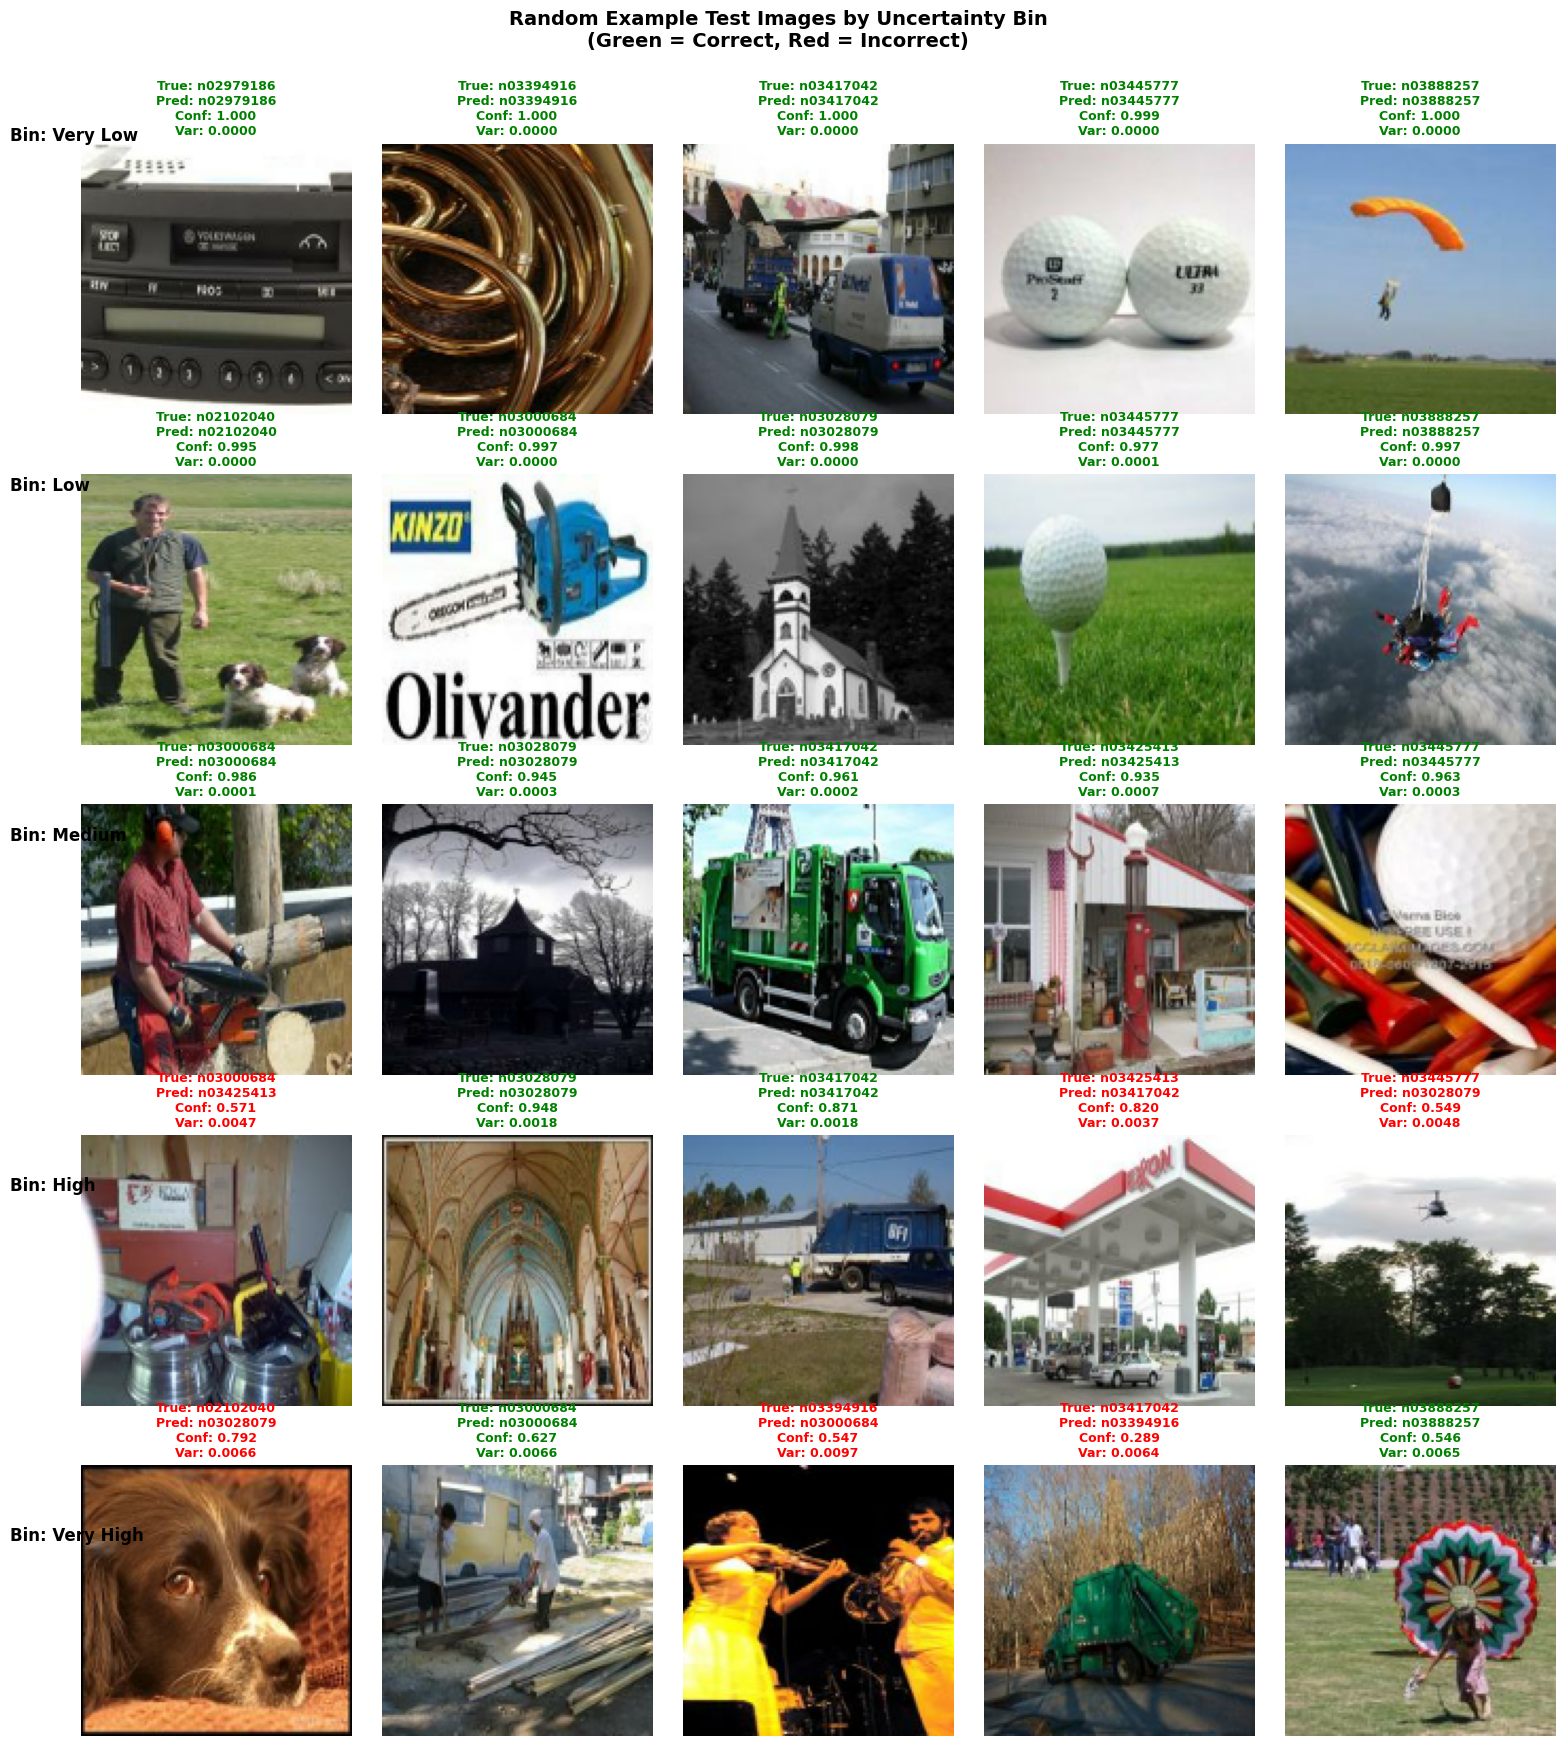

In [22]:
print("Selecting random example images from each uncertainty bin...")

num_bins = len(np.unique(bin_indices))
MAX_IMAGES_PER_BIN = 5
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)
selected_indices_by_bin = {}

for bin_idx in range(num_bins):
    candidate_indices = np.where(bin_indices == bin_idx)[0]
    rng.shuffle(candidate_indices)

    selected_indices = []
    seen_classes = set()

    # Prefer class-diverse examples first
    for idx in candidate_indices:
        true_class = int(all_true_classes[idx])
        if true_class not in seen_classes:
            selected_indices.append(int(idx))
            seen_classes.add(true_class)
        if len(selected_indices) == MAX_IMAGES_PER_BIN:
            break

    # Fill remaining slots randomly from the same bin
    if len(selected_indices) < MAX_IMAGES_PER_BIN:
        remaining_indices = [int(idx) for idx in candidate_indices if int(idx) not in selected_indices]
        selected_indices.extend(remaining_indices[: MAX_IMAGES_PER_BIN - len(selected_indices)])

    selected_indices_by_bin[bin_idx] = selected_indices

selected_lookup = {}
for bin_idx, indices in selected_indices_by_bin.items():
    for idx in indices:
        selected_lookup[idx] = bin_idx

images_by_bin = {i: [] for i in range(num_bins)}
sample_counter = 0

for images, labels in test_ds:
    batch_images = images.numpy()

    for i in range(len(batch_images)):
        global_idx = sample_counter + i
        if global_idx >= len(all_true_classes):
            break

        if global_idx not in selected_lookup:
            continue

        bin_idx = selected_lookup[global_idx]
        image = np.clip(batch_images[i], 0, 255).astype(np.uint8)

        sample = {
            "image": image,
            "true_class": class_names[int(all_true_classes[global_idx])],
            "pred_class": class_names[int(all_predicted_classes[global_idx])],
            "confidence": float(all_max_probs[global_idx]),
            "variance": float(all_mean_variances[global_idx]),
            "is_correct": bool(correct[global_idx]),
        }

        images_by_bin[bin_idx].append(sample)

    sample_counter += len(batch_images)

    if sum(len(samples) for samples in images_by_bin.values()) == len(selected_lookup):
        break

print(f"Images collected! ({sum(len(samples) for samples in images_by_bin.values())} total images)")

num_examples = MAX_IMAGES_PER_BIN
fig, axes = plt.subplots(
    num_bins,
    num_examples,
    figsize=(16, 3.5 * num_bins),
    squeeze=False,
)

bin_labels_unique = bin_labels[:num_bins]

for bin_idx in range(num_bins):
    samples = list(images_by_bin[bin_idx])

    while len(samples) < num_examples:
        samples.append(None)

    for col_idx, sample in enumerate(samples[:num_examples]):
        ax = axes[bin_idx, col_idx]

        if sample is None:
            ax.axis("off")
            continue

        ax.imshow(sample["image"])

        title_color = "green" if sample["is_correct"] else "red"
        title = f"True: {sample['true_class']}\n"
        title += f"Pred: {sample['pred_class']}\n"
        title += f"Conf: {sample['confidence']:.3f}\n"
        title += f"Var: {sample['variance']:.4f}"

        ax.set_title(title, fontsize=9, color=title_color, fontweight="bold")
        ax.axis("off")

    fig.text(
        0.02,
        0.92 - (bin_idx / max(num_bins, 1)),
        f"Bin: {bin_labels_unique[bin_idx]}",
        fontsize=12,
        fontweight="bold",
        transform=fig.transFigure,
    )

plt.suptitle(
    "Random Example Test Images by Uncertainty Bin\n(Green = Correct, Red = Incorrect)",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout(rect=[0.05, 0, 1, 0.99])
plt.show()


## Analysis Summary

Key findings from the uncertainty-accuracy analysis.

In [23]:
# Generate summary statistics
print("\n" + "="*80)
print("UNCERTAINTY-ACCURACY ANALYSIS SUMMARY")
print("="*80)

print(f"\n1. Overall Performance:")
print(f"   - Total test samples: {len(all_true_classes)}")
print(f"   - Overall accuracy: {correct.mean():.4f}")
print(f"   - Correct predictions: {correct.sum()}")
print(f"   - Wrong predictions: {(1-correct).sum()}")

print(f"\n2. Uncertainty Distribution:")
print(f"   - Variance range: [{all_mean_variances.min():.6f}, {all_mean_variances.max():.6f}]")
print(f"   - Entropy range: [{all_predictive_entropies.min():.6f}, {all_predictive_entropies.max():.6f}]")
print(f"   - Confidence range: [{all_max_probs.min():.6f}, {all_max_probs.max():.6f}]")

print(f"\n3. Performance by Uncertainty Bin:")
best_bin = results_df.loc[results_df['accuracy'].idxmax()]
worst_bin = results_df.loc[results_df['accuracy'].idxmin()]

print(f"   - Best bin: {best_bin['label']} with accuracy {best_bin['accuracy']:.4f} ({int(best_bin['count'])} samples)")
print(f"   - Worst bin: {worst_bin['label']} with accuracy {worst_bin['accuracy']:.4f} ({int(worst_bin['count'])} samples)")

accuracy_improvement = best_bin['accuracy'] - worst_bin['accuracy']
print(f"   - Improvement from worst to best: {accuracy_improvement:.4f} ({accuracy_improvement*100:.2f}%)")

print(f"\n4. Interpretation:")
if best_bin['avg_variance'] < worst_bin['avg_variance']:
    print(f"   ✓ Low uncertainty → High accuracy: Models with lower variance tend to be more accurate")
    print(f"   ✓ High uncertainty → Lower accuracy: Models with higher variance tend to be less accurate")
else:
    print(f"   ✗ Relationship may be reversed or weak")

print(f"\n5. Sample Distribution:")
for _, row in results_df.iterrows():
    pct = row['count'] / len(all_true_classes) * 100
    print(f"   - {row['label']:12s}: {int(row['count']):5d} samples ({pct:5.2f}%)")

print("\n" + "="*80)


UNCERTAINTY-ACCURACY ANALYSIS SUMMARY

1. Overall Performance:
   - Total test samples: 3925
   - Overall accuracy: 0.7990
   - Correct predictions: 3136
   - Wrong predictions: 789

2. Uncertainty Distribution:
   - Variance range: [0.000000, 0.023039]
   - Entropy range: [0.000000, 2.033438]
   - Confidence range: [0.226746, 1.000000]

3. Performance by Uncertainty Bin:
   - Best bin: Very Low with accuracy 0.9911 (785 samples)
   - Worst bin: Very High with accuracy 0.5057 (785 samples)
   - Improvement from worst to best: 0.4854 (48.54%)

4. Interpretation:
   ✓ Low uncertainty → High accuracy: Models with lower variance tend to be more accurate
   ✓ High uncertainty → Lower accuracy: Models with higher variance tend to be less accurate

5. Sample Distribution:
   - Very Low    :   785 samples (20.00%)
   - Low         :   785 samples (20.00%)
   - Medium      :   785 samples (20.00%)
   - High        :   785 samples (20.00%)
   - Very High   :   785 samples (20.00%)



In [24]:
## Comparative Analysis: Different Dropout Models

#Compare uncertainty-accuracy relationship across different dropout rates.

Starting comparative analysis of 3 dropout models...

Analyzing: Dropout 0.1


wandb:   1 of 1 files downloaded.  


✓ Loaded model: Dropout 0.1

Analyzing: Dropout 0.3


wandb:   1 of 1 files downloaded.  


✓ Loaded model: Dropout 0.3

Analyzing: Dropout 0.5


wandb:   1 of 1 files downloaded.  


✓ Loaded model: Dropout 0.5

✓ Analysis complete for 3 models!


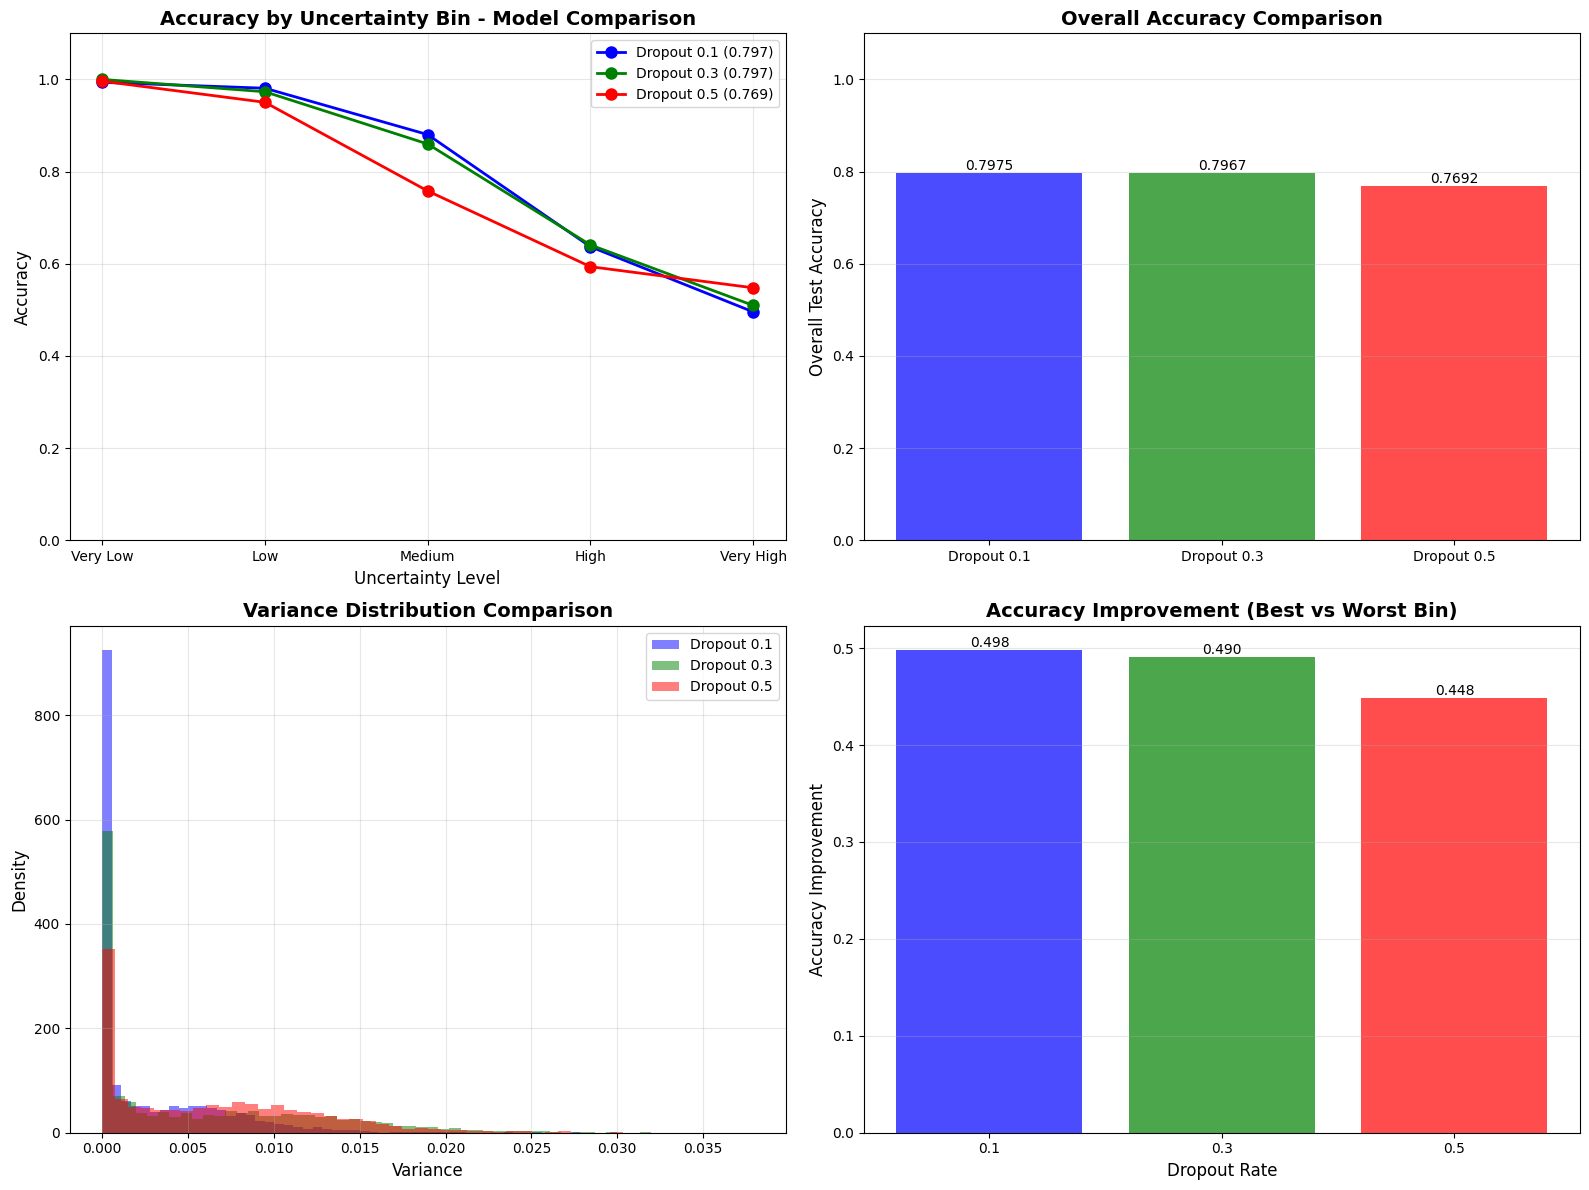


COMPARATIVE ANALYSIS SUMMARY

Dropout 0.1:
  Overall accuracy: 0.7975
  Best bin (Very Low): 0.9936
  Worst bin (Very High): 0.4955
  Improvement: 0.4981 (49.8%)

Dropout 0.3:
  Overall accuracy: 0.7967
  Best bin (Very Low): 1.0000
  Worst bin (Very High): 0.5096
  Improvement: 0.4904 (49.0%)

Dropout 0.5:
  Overall accuracy: 0.7692
  Best bin (Very Low): 0.9962
  Worst bin (Very High): 0.5478
  Improvement: 0.4484 (44.8%)



In [25]:
# Define the 3 models to compare
import sys

# Check if required variables are defined
required_vars = ['test_ds', 'class_names', 'MC_SAMPLES', 'NUM_UNCERTAINTY_BINS', 'MCDropout', 'mc_predict', 'download_artifact_file']
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    print("❌ ERROR: Cannot run this cell. Missing variables:")
    for var in missing_vars:
        print(f"   - {var}")
    print("\n📋 Please run the following cells in order BEFORE running this cell:")
    print("   1. Cell 4: Imports and setup")
    print("   2. Cell 5: Configuration")
    print("   3. Cell 8: Load test dataset")
    print("   4. Cell 10: Configuration variables")
    sys.exit(1)

models_to_compare = [
    {"name": "Dropout 0.1", "artifact": "notebook-04-dropout-0-1-model", "alias": "v3"},
    {"name": "Dropout 0.3", "artifact": "notebook-04-dropout-0-3-model", "alias": "v3"},
    {"name": "Dropout 0.5", "artifact": "notebook-04-dropout-0-5-model", "alias": "v3"},
]

def analyze_model_uncertainty(model_info, test_ds, class_names, mc_samples=30, num_bins=5):
    """Run complete uncertainty analysis for a single model."""
    print(f"\n{'='*60}")
    print(f"Analyzing: {model_info['name']}")
    print(f"{'='*60}")

    # Load model
    try:
        model_path = download_artifact_file(
            model_info["artifact"],
            alias=model_info["alias"]
        )
        model = tf.keras.models.load_model(
            model_path,
            custom_objects={"MCDropout": MCDropout},
        )
        print(f"✓ Loaded model: {model_info['name']}")
    except Exception as e:
        print(f"✗ Failed to load {model_info['name']}: {e}")
        return None

    # Run MC predictions
    all_true_classes = []
    all_predicted_classes = []
    all_predictive_entropies = []
    all_mean_variances = []
    all_max_probs = []

    for images, labels in test_ds:
        mean_prediction, variance, predictive_entropy = mc_predict(
            model, images, mc_samples
        )

        predicted_classes = mean_prediction.argmax(axis=1)
        true_classes = labels.numpy().argmax(axis=1)
        batch_mean_variance = variance.mean(axis=1)
        max_probs = mean_prediction.max(axis=1)

        all_true_classes.extend(true_classes.tolist())
        all_predicted_classes.extend(predicted_classes.tolist())
        all_predictive_entropies.extend(predictive_entropy.tolist())
        all_mean_variances.extend(batch_mean_variance.tolist())
        all_max_probs.extend(max_probs.tolist())

    # Convert to arrays
    all_true_classes = np.array(all_true_classes)
    all_predicted_classes = np.array(all_predicted_classes)
    all_predictive_entropies = np.array(all_predictive_entropies)
    all_mean_variances = np.array(all_mean_variances)
    all_max_probs = np.array(all_max_probs)
    correct = (all_true_classes == all_predicted_classes).astype(int)

    # Bin analysis
    bin_indices = pd.qcut(all_mean_variances, q=num_bins, labels=False, duplicates='drop')
    bin_labels = ["Very Low", "Low", "Medium", "High", "Very High"][:len(np.unique(bin_indices))]

    results = []
    for bin_idx, label in enumerate(bin_labels):
        mask = bin_indices == bin_idx
        bin_count = mask.sum()
        bin_accuracy = correct[mask].mean()

        results.append({
            'bin': bin_idx,
            'label': label,
            'count': int(bin_count),
            'accuracy': float(bin_accuracy),
            'avg_variance': float(all_mean_variances[mask].mean()),
            'avg_entropy': float(all_predictive_entropies[mask].mean()),
            'avg_confidence': float(all_max_probs[mask].mean()),
        })

    return {
        'model_name': model_info['name'],
        'overall_accuracy': float(correct.mean()),
        'results_df': pd.DataFrame(results),
        'all_variances': all_mean_variances,
        'all_correct': correct,
        'bin_indices': bin_indices,
    }

# Run analysis for all models
print("Starting comparative analysis of 3 dropout models...")
all_results = []

for model_info in models_to_compare:
    result = analyze_model_uncertainty(model_info, test_ds, class_names, MC_SAMPLES, NUM_UNCERTAINTY_BINS)
    if result:
        all_results.append(result)

print(f"\n✓ Analysis complete for {len(all_results)} models!")

# Create comparative visualization
if len(all_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Accuracy by bin for each model
    ax = axes[0, 0]
    colors = ['blue', 'green', 'red']
    bin_labels = all_results[0]['results_df']['label'].values

    for i, result in enumerate(all_results):
        accuracies = result['results_df']['accuracy'].values
        ax.plot(bin_labels, accuracies, 'o-', color=colors[i],
                label=f"{result['model_name']} ({result['overall_accuracy']:.3f})",
                linewidth=2, markersize=8)

    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xlabel('Uncertainty Level', fontsize=12)
    ax.set_title('Accuracy by Uncertainty Bin - Model Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.legend()
    ax.grid(alpha=0.3)

    # Plot 2: Overall accuracy comparison
    ax = axes[0, 1]
    model_names = [r['model_name'] for r in all_results]
    overall_accuracies = [r['overall_accuracy'] for r in all_results]

    bars = ax.bar(model_names, overall_accuracies, color=colors[:len(all_results)], alpha=0.7)
    ax.set_ylabel('Overall Test Accuracy', fontsize=12)
    ax.set_title('Overall Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

    # Plot 3: Variance distribution comparison
    ax = axes[1, 0]
    for i, result in enumerate(all_results):
        variances = result['all_variances']
        ax.hist(variances, bins=50, alpha=0.5, label=result['model_name'],
                color=colors[i], density=True)

    ax.set_xlabel('Variance', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Variance Distribution Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

    # Plot 4: Accuracy improvement (best vs worst bin)
    ax = axes[1, 1]
    improvements = []
    model_names_short = []

    for result in all_results:
        df = result['results_df']
        best_acc = df['accuracy'].max()
        worst_acc = df['accuracy'].min()
        improvement = best_acc - worst_acc
        improvements.append(improvement)
        model_names_short.append(result['model_name'].split()[-1])  # Just the dropout rate

    bars = ax.bar(model_names_short, improvements, color=colors[:len(all_results)], alpha=0.7)
    ax.set_ylabel('Accuracy Improvement', fontsize=12)
    ax.set_xlabel('Dropout Rate', fontsize=12)
    ax.set_title('Accuracy Improvement (Best vs Worst Bin)', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print detailed comparison
    print("\n" + "="*80)
    print("COMPARATIVE ANALYSIS SUMMARY")
    print("="*80)

    for result in all_results:
        print(f"\n{result['model_name']}:")
        print(f"  Overall accuracy: {result['overall_accuracy']:.4f}")
        df = result['results_df']
        best_bin = df.loc[df['accuracy'].idxmax()]
        worst_bin = df.loc[df['accuracy'].idxmin()]
        improvement = best_bin['accuracy'] - worst_bin['accuracy']
        print(f"  Best bin ({best_bin['label']}): {best_bin['accuracy']:.4f}")
        print(f"  Worst bin ({worst_bin['label']}): {worst_bin['accuracy']:.4f}")
        print(f"  Improvement: {improvement:.4f} ({improvement*100:.1f}%)")

    print("\n" + "="*80)

In [26]:

# Detailed Statistics per Model and Bin - Using Pre-Computed Results
import sys

print("\n" + "="*120)
print("DETAILED STATISTICS BY MODEL AND BIN")
print("="*120)
sys.stdout.flush()

# Use the results from the comparative analysis (already computed, no need to re-run)
detailed_results = all_results

if len(detailed_results) == 0:
    print("⚠ No results available. Please run the comparative analysis cell first.")
else:
    print(f"Using {len(detailed_results)} pre-computed model results...\n")
    sys.stdout.flush()
    
    for model_idx, result in enumerate(detailed_results):
        try:
            print(f"\n[Model {model_idx + 1}/{len(detailed_results)}] {result['model_name'].upper()}")
            print(f"Overall Accuracy: {result['overall_accuracy']:.4f}")
            print("-" * 120)
            sys.stdout.flush()
            
            df = result['results_df']
            
            # Create a detailed statistics table
            detailed_stats = []
            
            for _, row in df.iterrows():
                bin_idx = int(row['bin'])
                label = row['label']
                
                # Get mask for this bin
                mask = result['bin_indices'] == bin_idx
                
                # Calculate additional statistics
                variances = result['all_variances'][mask]
                correctness = result['all_correct'][mask]
                
                variance_mean = variances.mean()
                variance_std = variances.std()
                variance_min = variances.min()
                variance_max = variances.max()
                
                accuracy = correctness.mean()
                correct_count = int(correctness.sum())
                total_count = int(mask.sum())
                
                detailed_stats.append({
                    'Bin': label,
                    'Count': total_count,
                    'Accuracy': f"{accuracy:.4f}",
                    'Correct': correct_count,
                    'Var Mean': f"{variance_mean:.6f}",
                    'Var Std': f"{variance_std:.6f}",
                    'Var Min': f"{variance_min:.6f}",
                    'Var Max': f"{variance_max:.6f}",
                    'Avg Entropy': f"{row['avg_entropy']:.6f}",
                    'Avg Conf': f"{row['avg_confidence']:.4f}",
                })
            
            detailed_df = pd.DataFrame(detailed_stats)
            # Print with explicit format to avoid truncation
            print(detailed_df.to_string(index=False, max_rows=None, max_cols=None))
            print(f"✓ Completed statistics for {result['model_name']}\n")
            sys.stdout.flush()
            
        except Exception as e:
            print(f"✗ ERROR processing {result['model_name']}: {str(e)}")
            import traceback
            traceback.print_exc()
            sys.stdout.flush()
            continue

print("="*120)

# Create a comprehensive comparison table using detailed_results
print(f"\nCOMPARATIVE SUMMARY: Key Metrics Across All {len(detailed_results)} Models")
print("="*120)
sys.stdout.flush()

comparison_data = []
for result in detailed_results:
    try:
        df = result['results_df']
        
        best_acc_idx = df['accuracy'].idxmax()
        worst_acc_idx = df['accuracy'].idxmin()
        
        best_bin_label = df.iloc[best_acc_idx]['label']
        worst_bin_label = df.iloc[worst_acc_idx]['label']
        best_acc = df.iloc[best_acc_idx]['accuracy']
        worst_acc = df.iloc[worst_acc_idx]['accuracy']
        
        improvement = best_acc - worst_acc
        avg_variance = df['avg_variance'].mean()
        avg_entropy = df['avg_entropy'].mean()
        
        comparison_data.append({
            'Model': result['model_name'],
            'Overall Acc': f"{result['overall_accuracy']:.4f}",
            'Best Bin': f"{best_bin_label} ({best_acc:.4f})",
            'Worst Bin': f"{worst_bin_label} ({worst_acc:.4f})",
            'Improvement': f"{improvement:.4f} ({improvement*100:.1f}%)",
            'Avg Variance': f"{avg_variance:.6f}",
            'Avg Entropy': f"{avg_entropy:.6f}",
        })
    except Exception as e:
        print(f"✗ ERROR in comparison summary for {result.get('model_name', 'Unknown')}: {str(e)}")
        sys.stdout.flush()
        continue

if comparison_data:
    comparison_summary_df = pd.DataFrame(comparison_data)
    print(comparison_summary_df.to_string(index=False))
else:
    print("⚠ No models were successfully analyzed.")

print("="*120)
sys.stdout.flush()



DETAILED STATISTICS BY MODEL AND BIN
Using 3 pre-computed model results...


[Model 1/3] DROPOUT 0.1
Overall Accuracy: 0.7975
------------------------------------------------------------------------------------------------------------------------
      Bin  Count Accuracy  Correct Var Mean  Var Std  Var Min  Var Max Avg Entropy Avg Conf
 Very Low    785   0.9936      780 0.000000 0.000000 0.000000 0.000000    0.002377   0.9998
      Low    785   0.9809      770 0.000014 0.000017 0.000000 0.000062    0.042483   0.9939
   Medium    785   0.8803      691 0.000581 0.000469 0.000062 0.001665    0.269476   0.9431
     High    785   0.6369      500 0.003765 0.001241 0.001671 0.005865    0.891964   0.7134
Very High    785   0.4955      389 0.008983 0.002847 0.005872 0.027844    1.112839   0.5538
✓ Completed statistics for Dropout 0.1


[Model 2/3] DROPOUT 0.3
Overall Accuracy: 0.7967
--------------------------------------------------------------------------------------------------------------